# Notebook 04 — Kinship & Relatedness Analysis
## Pairwise Relatedness · Kinship Maps · Within vs Between-Group Structure

---

**Prerequisite:** Run notebooks 01–03 first.

**Three estimators implemented:**

| Estimator | Reference | Notes |
|-----------|-----------|-------|
| Queller & Goodnight rxy | QG 1989, *Evolution* | Symmetrised; most widely used in primates |
| Lynch & Ritland r̂ | LR 1999, *Genetics* | Lower variance with many loci |
| Proportion Alleles Shared (PAS) | — | Non-parametric IBS check |

**Expected values (diploid outbreeders):**
- Parent–offspring: r ≈ 0.50
- Full siblings: r ≈ 0.50
- Half siblings: r ≈ 0.25
- First cousins: r ≈ 0.125
- Unrelated: r ≈ 0.0 (can be negative)

---

In [1]:
# Cell 1 — Imports
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from scipy.stats import mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

ROOT = Path(os.getcwd())
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))

from utils import set_plot_style, save_figure, get_data_dir, get_output_dir
from parentage_functions import build_freq_table
from kinship_functions import (
    build_geno_dict, compute_pairwise_relatedness,
    relatedness_to_matrix, group_relatedness_summary
)

set_plot_style()
DATA_RAW  = get_data_dir('raw')
DATA_PROC = get_data_dir('processed')
FIG_DIR   = get_output_dir('figures')
TAB_DIR   = get_output_dir('tables')

geno_df   = pd.read_csv(DATA_PROC / 'genotypes_qc.csv')
ind_df    = pd.read_csv(DATA_PROC / 'individuals_qc.csv')
groups_df = pd.read_csv(DATA_RAW  / 'groups.csv')

with open(DATA_PROC / 'qc_loci.txt') as f:
    QC_LOCI = [l.strip() for l in f if l.strip()]

print(f'Loaded: {len(ind_df)} individuals | {len(QC_LOCI)} loci')

Loaded: 63 individuals | 15 loci


In [2]:
# Cell 2 — Build inputs and compute pairwise relatedness
freq_table = build_freq_table(geno_df, QC_LOCI)
geno_dict  = build_geno_dict(geno_df, QC_LOCI)
all_ids    = ind_df['individual_id'].tolist()

print(f'Computing {len(all_ids)*(len(all_ids)-1)//2} pairs... (may take 1-3 min)')

pairwise_df = compute_pairwise_relatedness(
    ind_ids     = all_ids,
    geno_dict   = geno_dict,
    freq_table  = freq_table,
    locus_names = QC_LOCI,
    method      = 'both'
)

print(f'Pairs computed: {len(pairwise_df)}')
print('\nSummary statistics (all pairs):')
print(pairwise_df[['r_qg','r_lr','pas']].describe().round(4).to_string())

pairwise_df.to_csv(DATA_PROC / 'pairwise_relatedness.csv', index=False)
print('Saved to data/processed/pairwise_relatedness.csv')

Computing 1953 pairs... (may take 1-3 min)
Pairs computed: 1953

Summary statistics (all pairs):
            r_qg       r_lr        pas
count  1953.0000  1953.0000  1953.0000
mean     -0.0097     0.0013     0.1813
std       0.0782     0.1657     0.0683
min      -0.2127    -0.3893     0.0192
25%      -0.0634    -0.1151     0.1346
50%      -0.0165    -0.0194     0.1731
75%       0.0327     0.1061     0.2167
max       0.3715     0.7298     0.5192
Saved to data/processed/pairwise_relatedness.csv


In [3]:
# Cell 3 — Annotate pairs with relationship context
id_to_group = ind_df.set_index('individual_id')['group_id'].to_dict()

pairwise_df['group1']  = pairwise_df['id1'].map(id_to_group)
pairwise_df['group2']  = pairwise_df['id2'].map(id_to_group)
pairwise_df['context'] = np.where(
    pairwise_df['group1'] == pairwise_df['group2'], 'within', 'between'
)

# Flag known parent-offspring pairs from metadata
mom_pairs = set()
for _, row in ind_df.iterrows():
    if pd.notna(row.get('mother_id')):
        pair = tuple(sorted([row['individual_id'], row['mother_id']]))
        mom_pairs.add(pair)

import os
pat_file = TAB_DIR / 'paternity_assignments.csv'
pat_pairs = set()
if pat_file.exists():
    pat_df = pd.read_csv(pat_file)
    for _, row in pat_df.iterrows():
        if pd.notna(row.get('assigned_father')):
            pair = tuple(sorted([row['offspring_id'], row['assigned_father']]))
            pat_pairs.add(pair)

def classify_pair(row):
    pair = tuple(sorted([row['id1'], row['id2']]))
    if pair in mom_pairs or pair in pat_pairs:
        return 'parent_offspring'
    elif row['context'] == 'within':
        return 'within_group_other'
    else:
        return 'between_group'

pairwise_df['relationship'] = pairwise_df.apply(classify_pair, axis=1)

print('Pair relationship breakdown:')
print(pairwise_df['relationship'].value_counts())
print('\nMean r_qg by relationship:')
print(pairwise_df.groupby('relationship')['r_qg'].agg(['mean','median','std','count']).round(4))

Pair relationship breakdown:
relationship
between_group         1647
within_group_other     282
parent_offspring        24
Name: count, dtype: int64

Mean r_qg by relationship:
                      mean  median     std  count
relationship                                     
between_group      -0.0153 -0.0184  0.0701   1647
parent_offspring    0.2347  0.2154  0.0806     24
within_group_other  0.0021 -0.0088  0.0879    282


C:\Users\User\AppData\Local\Temp\ipykernel_11668\2545806858.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([within_r, between_r],


  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\04_relatedness_distributions.png


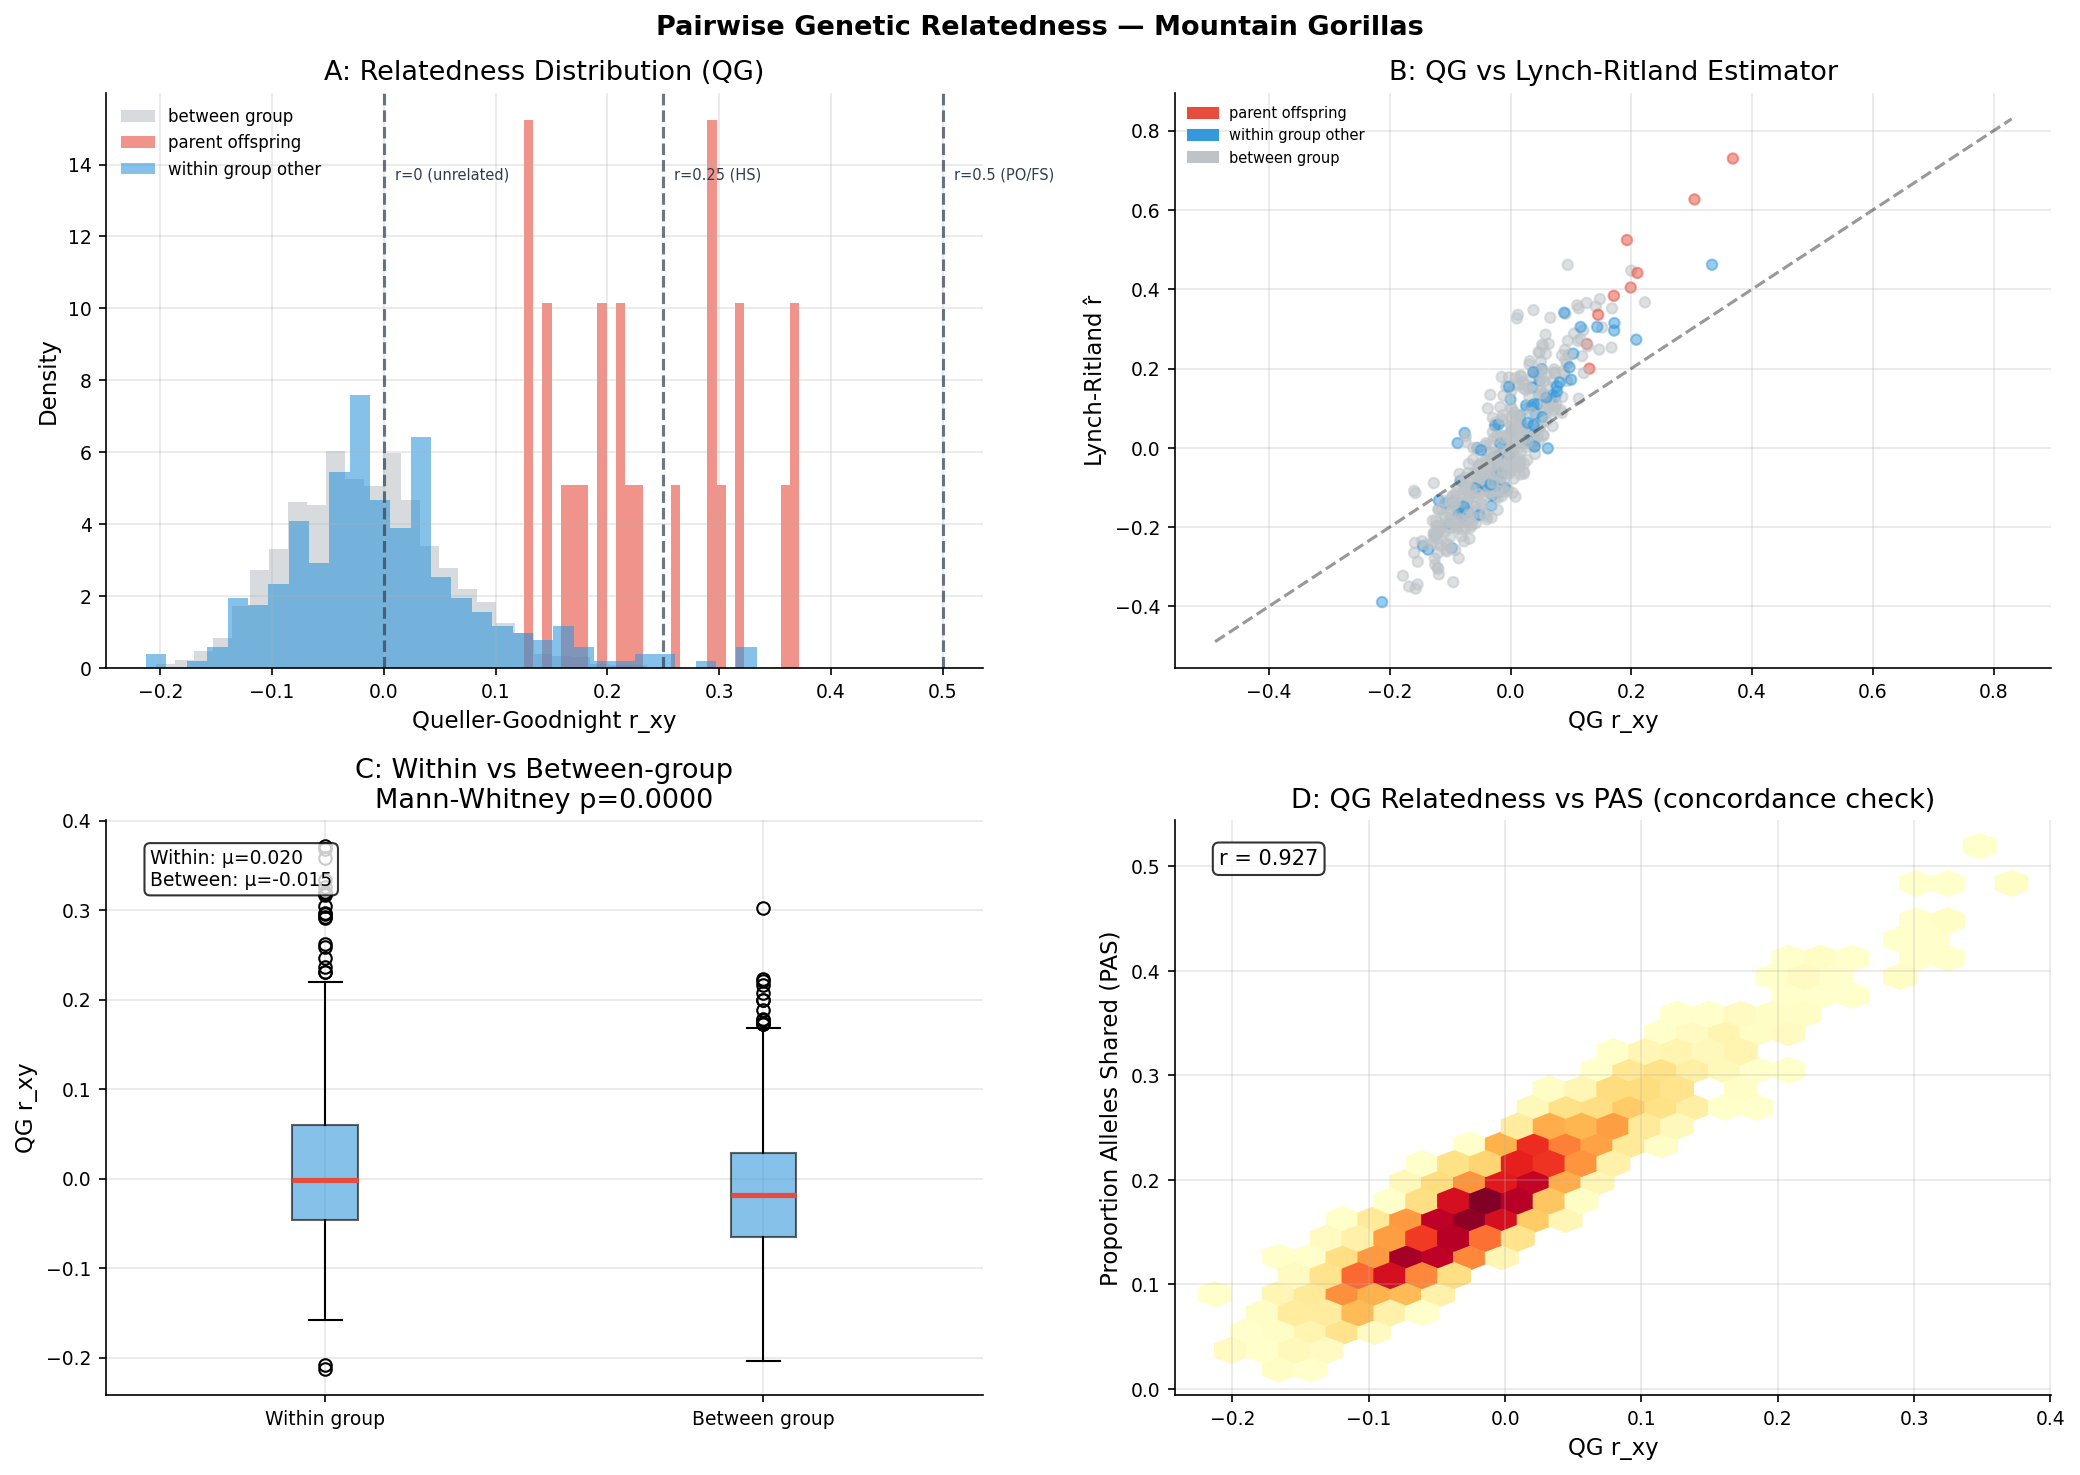

In [4]:
# Cell 4 — Relatedness distribution plots
rel_colors = {
    'parent_offspring':   '#E74C3C',
    'within_group_other': '#3498DB',
    'between_group':      '#BDC3C7',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pairwise Genetic Relatedness — Mountain Gorillas', fontsize=13, fontweight='bold')

# A: r_qg distribution by relationship
ax = axes[0, 0]
for rel, grp in pairwise_df.groupby('relationship'):
    vals = grp['r_qg'].dropna()
    ax.hist(vals, bins=30, alpha=0.6, label=rel.replace('_',' '),
            color=rel_colors.get(rel,'grey'), edgecolor='none', density=True)
for r_exp, label in [(0.5,'r=0.5 (PO/FS)'),(0.25,'r=0.25 (HS)'),(0.0,'r=0 (unrelated)')]:
    ax.axvline(r_exp, color='#2C3E50', lw=1.5, ls='--', alpha=0.7)
    ax.text(r_exp+0.01, ax.get_ylim()[1]*0.85, label, fontsize=7, color='#2C3E50')
ax.set_xlabel('Queller-Goodnight r_xy')
ax.set_ylabel('Density')
ax.set_title('A: Relatedness Distribution (QG)')
ax.legend(fontsize=8)

# B: QG vs LR estimator
ax = axes[0, 1]
sample = pairwise_df.dropna(subset=['r_qg','r_lr']).sample(min(500,len(pairwise_df)), random_state=42)
ax.scatter(sample['r_qg'], sample['r_lr'],
           c=[rel_colors.get(r,'grey') for r in sample['relationship']],
           s=25, alpha=0.5)
lims = [pairwise_df[['r_qg','r_lr']].min().min()-0.1, pairwise_df[['r_qg','r_lr']].max().max()+0.1]
ax.plot(lims, lims, 'k--', alpha=0.4, label='1:1 line')
ax.set_xlabel('QG r_xy'); ax.set_ylabel('Lynch-Ritland r̂')
ax.set_title('B: QG vs Lynch-Ritland Estimator')
legend_p = [mpatches.Patch(color=c, label=l.replace('_',' ')) for l,c in rel_colors.items()]
ax.legend(handles=legend_p, fontsize=7)

# C: Boxplot within vs between
ax = axes[1, 0]
within_r  = pairwise_df[pairwise_df['context']=='within']['r_qg'].dropna()
between_r = pairwise_df[pairwise_df['context']=='between']['r_qg'].dropna()
ax.boxplot([within_r, between_r],
           labels=['Within group','Between group'],
           patch_artist=True,
           boxprops=dict(facecolor='#3498DB', alpha=0.6),
           medianprops=dict(color='#E74C3C', lw=2.5))
stat_mw, p_mw = mannwhitneyu(within_r, between_r, alternative='greater')
ax.set_ylabel('QG r_xy')
ax.set_title(f'C: Within vs Between-group\nMann-Whitney p={p_mw:.4f}')
ax.text(0.05, 0.95, f'Within: μ={within_r.mean():.3f}\nBetween: μ={between_r.mean():.3f}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))

# D: PAS vs QG hexbin
ax = axes[1, 1]
sub = pairwise_df.dropna(subset=['r_qg','pas'])
ax.hexbin(sub['r_qg'], sub['pas'], gridsize=25, cmap='YlOrRd', mincnt=1)
ax.set_xlabel('QG r_xy'); ax.set_ylabel('Proportion Alleles Shared (PAS)')
ax.set_title('D: QG Relatedness vs PAS (concordance check)')
corr = sub[['r_qg','pas']].corr().iloc[0,1]
ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
        va='top', fontsize=10, bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
save_figure(fig, '04_relatedness_distributions')
plt.show()

  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\04_relatedness_heatmap.png


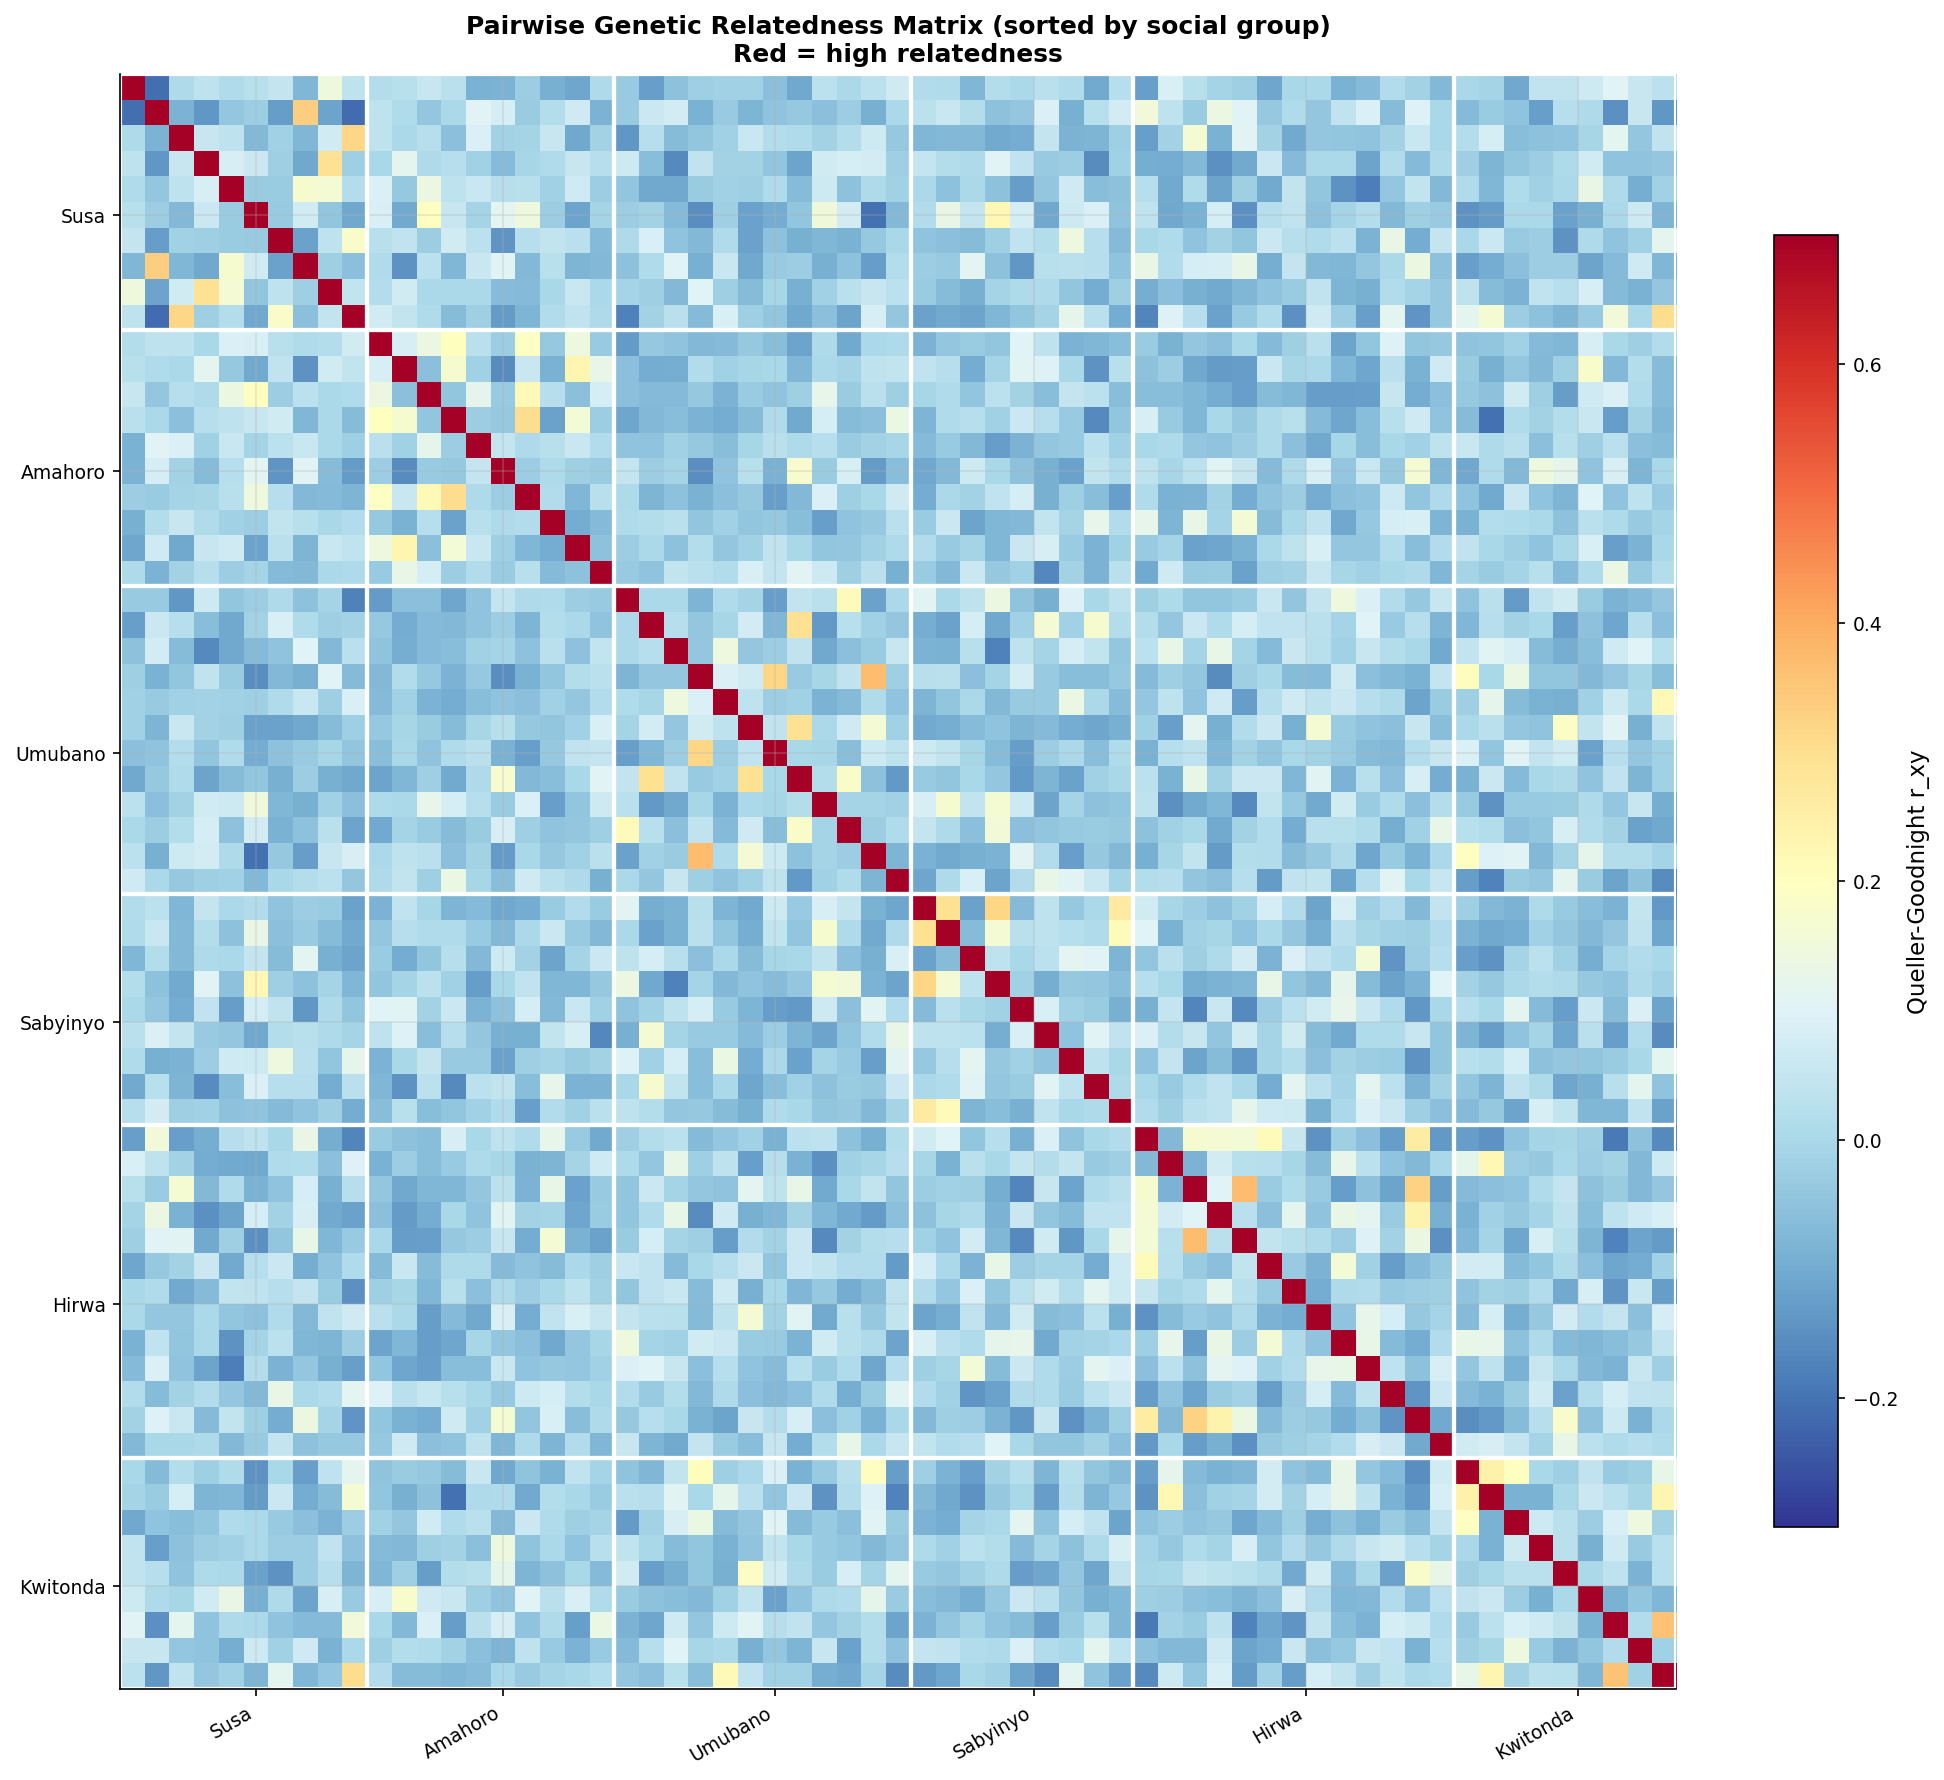

In [5]:
# Cell 5 — Relatedness heatmap sorted by group
def new_func():
    r_matrix = relatedness_to_matrix(pairwise_df, all_ids, r_col='r_qg')
    return r_matrix

def build_relationship_structure(new_func):
    r_matrix = new_func()
    return r_matrix

r_matrix = build_relationship_structure(new_func)
id_group_series = ind_df.set_index('individual_id')['group_id']
sorted_ids = id_group_series.reindex(all_ids).sort_values().index.tolist()
r_mat_sorted = r_matrix.reindex(index=sorted_ids, columns=sorted_ids)

fig, ax = plt.subplots(figsize=(14, 12))
arr = r_mat_sorted.astype(float).values.copy()
im = ax.imshow(arr,
               cmap='RdYlBu_r', vmin=-0.3, vmax=0.7,
               aspect='auto', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Queller-Goodnight r_xy', shrink=0.8)

prev = 0
tick_pos, tick_labels = [], []
for gid in sorted(id_group_series.unique()):
    n_in = (id_group_series.reindex(sorted_ids) == gid).sum()
    for edge in [prev, prev + n_in]:
        ax.axhline(edge - 0.5, color='white', lw=2)
        ax.axvline(edge - 0.5, color='white', lw=2)
    grp_name = groups_df[groups_df['id'] == gid]['name'].values
    tick_pos.append(prev + n_in / 2)
    tick_labels.append(grp_name[0] if len(grp_name) else gid)
    prev += n_in

ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels, rotation=30, ha='right')
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_labels)
ax.set_title('Pairwise Genetic Relatedness Matrix (sorted by social group)\nRed = high relatedness',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_figure(fig, '04_relatedness_heatmap')
plt.show()

  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\04_relatedness_dendrogram.png


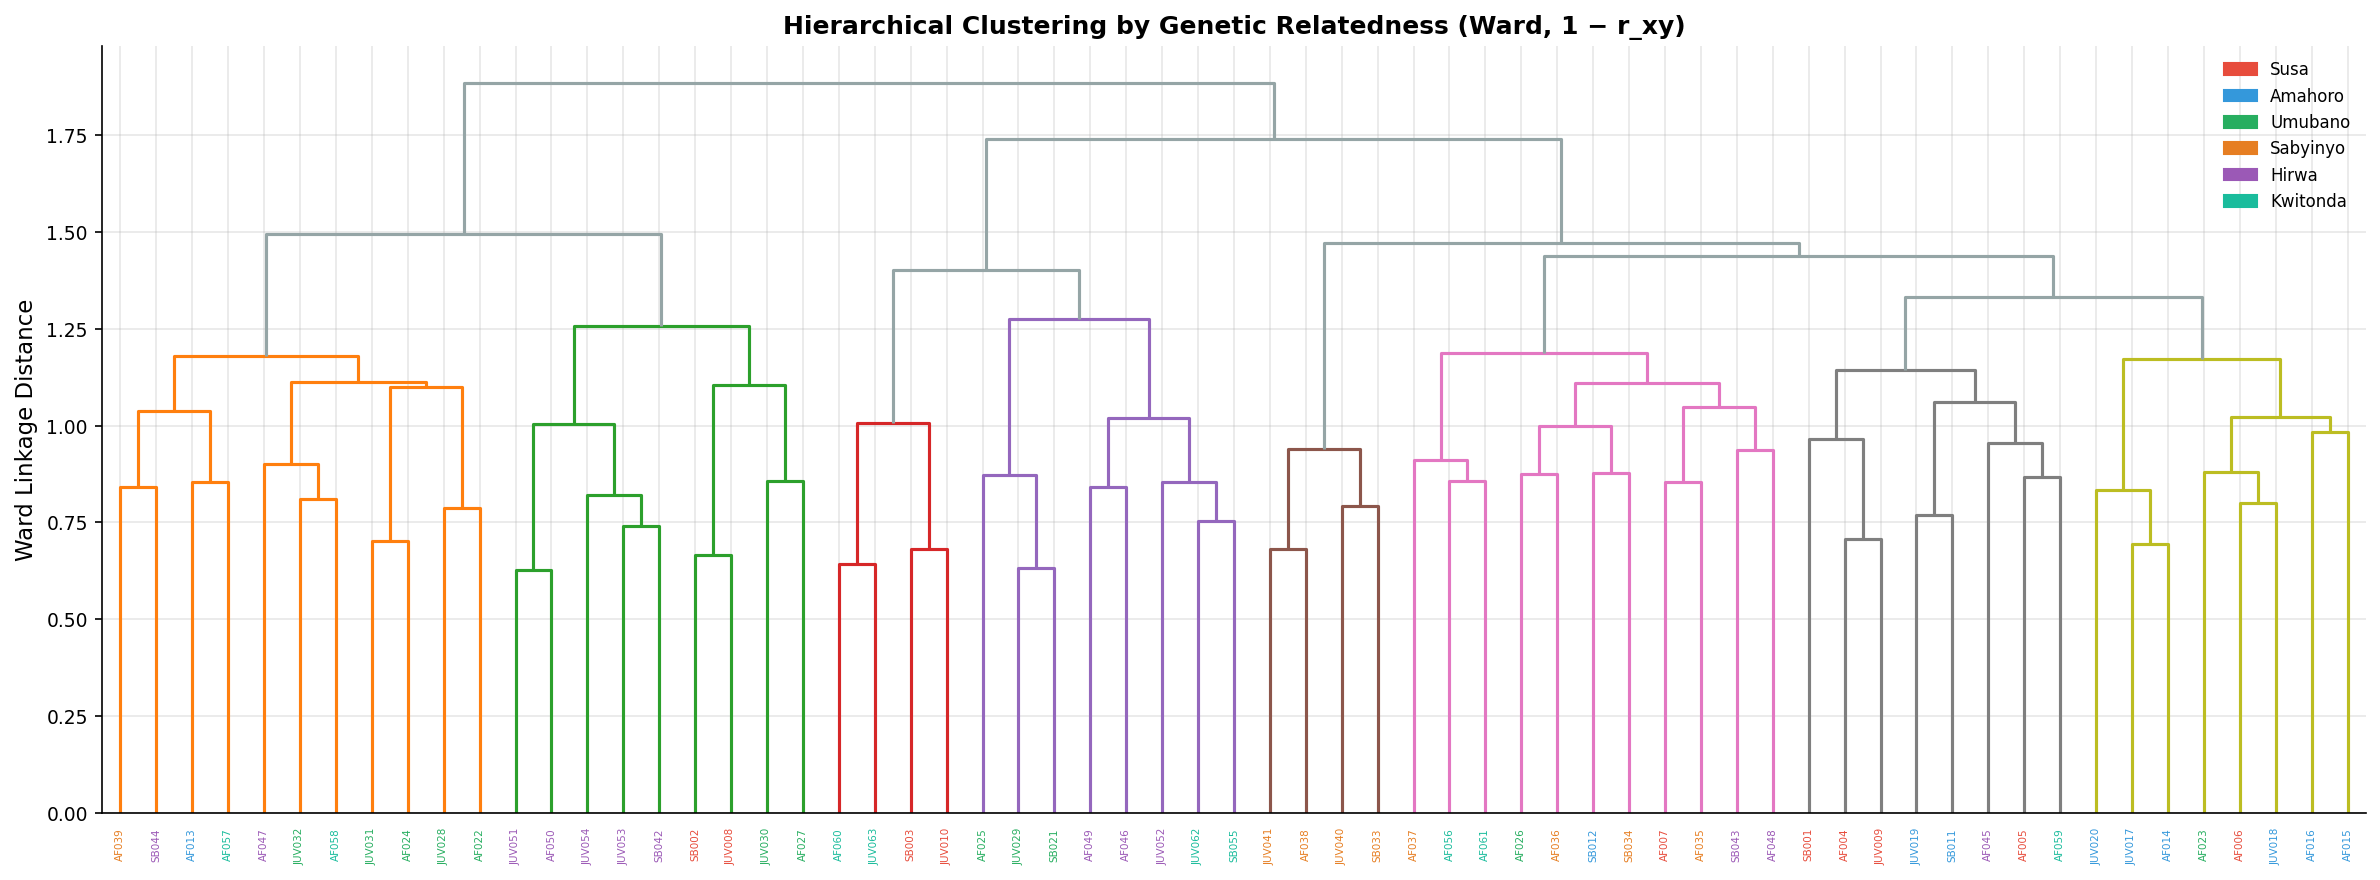

In [7]:
# Cell 6 — Hierarchical clustering dendrogram
r_mat_filled = r_mat_sorted.fillna(0)
dist_mat = np.clip(1 - r_mat_filled.values.astype(float), 0, None)
np.fill_diagonal(dist_mat, 0)
condensed = squareform(dist_mat, checks=False)
Z = linkage(condensed, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
group_color_map = {gid: c for gid, c in
                   zip(sorted(id_group_series.unique()),
                       ['#E74C3C','#3498DB','#27AE60','#E67E22','#9B59B6','#1ABC9C'])}

dendrogram(Z, ax=ax, labels=sorted_ids,
           leaf_rotation=90, leaf_font_size=5, above_threshold_color='#95A5A6')
ax.set_ylabel('Ward Linkage Distance')
ax.set_title('Hierarchical Clustering by Genetic Relatedness (Ward, 1 − r_xy)',
             fontsize=12, fontweight='bold')

for label in ax.get_xticklabels():
    iid = label.get_text()
    gid = id_group_series.get(iid, '')
    label.set_color(group_color_map.get(gid,'black'))

legend_p = [mpatches.Patch(color=c, label=groups_df[groups_df['id']==g]['name'].values[0]
                             if len(groups_df[groups_df['id']==g]) else g)
             for g,c in group_color_map.items()]
ax.legend(handles=legend_p, fontsize=8, loc='upper right')
plt.tight_layout()
save_figure(fig, '04_relatedness_dendrogram')
plt.show()

Network: 63 nodes, 29 edges (r > 0.2)
  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\04_kinship_network.png


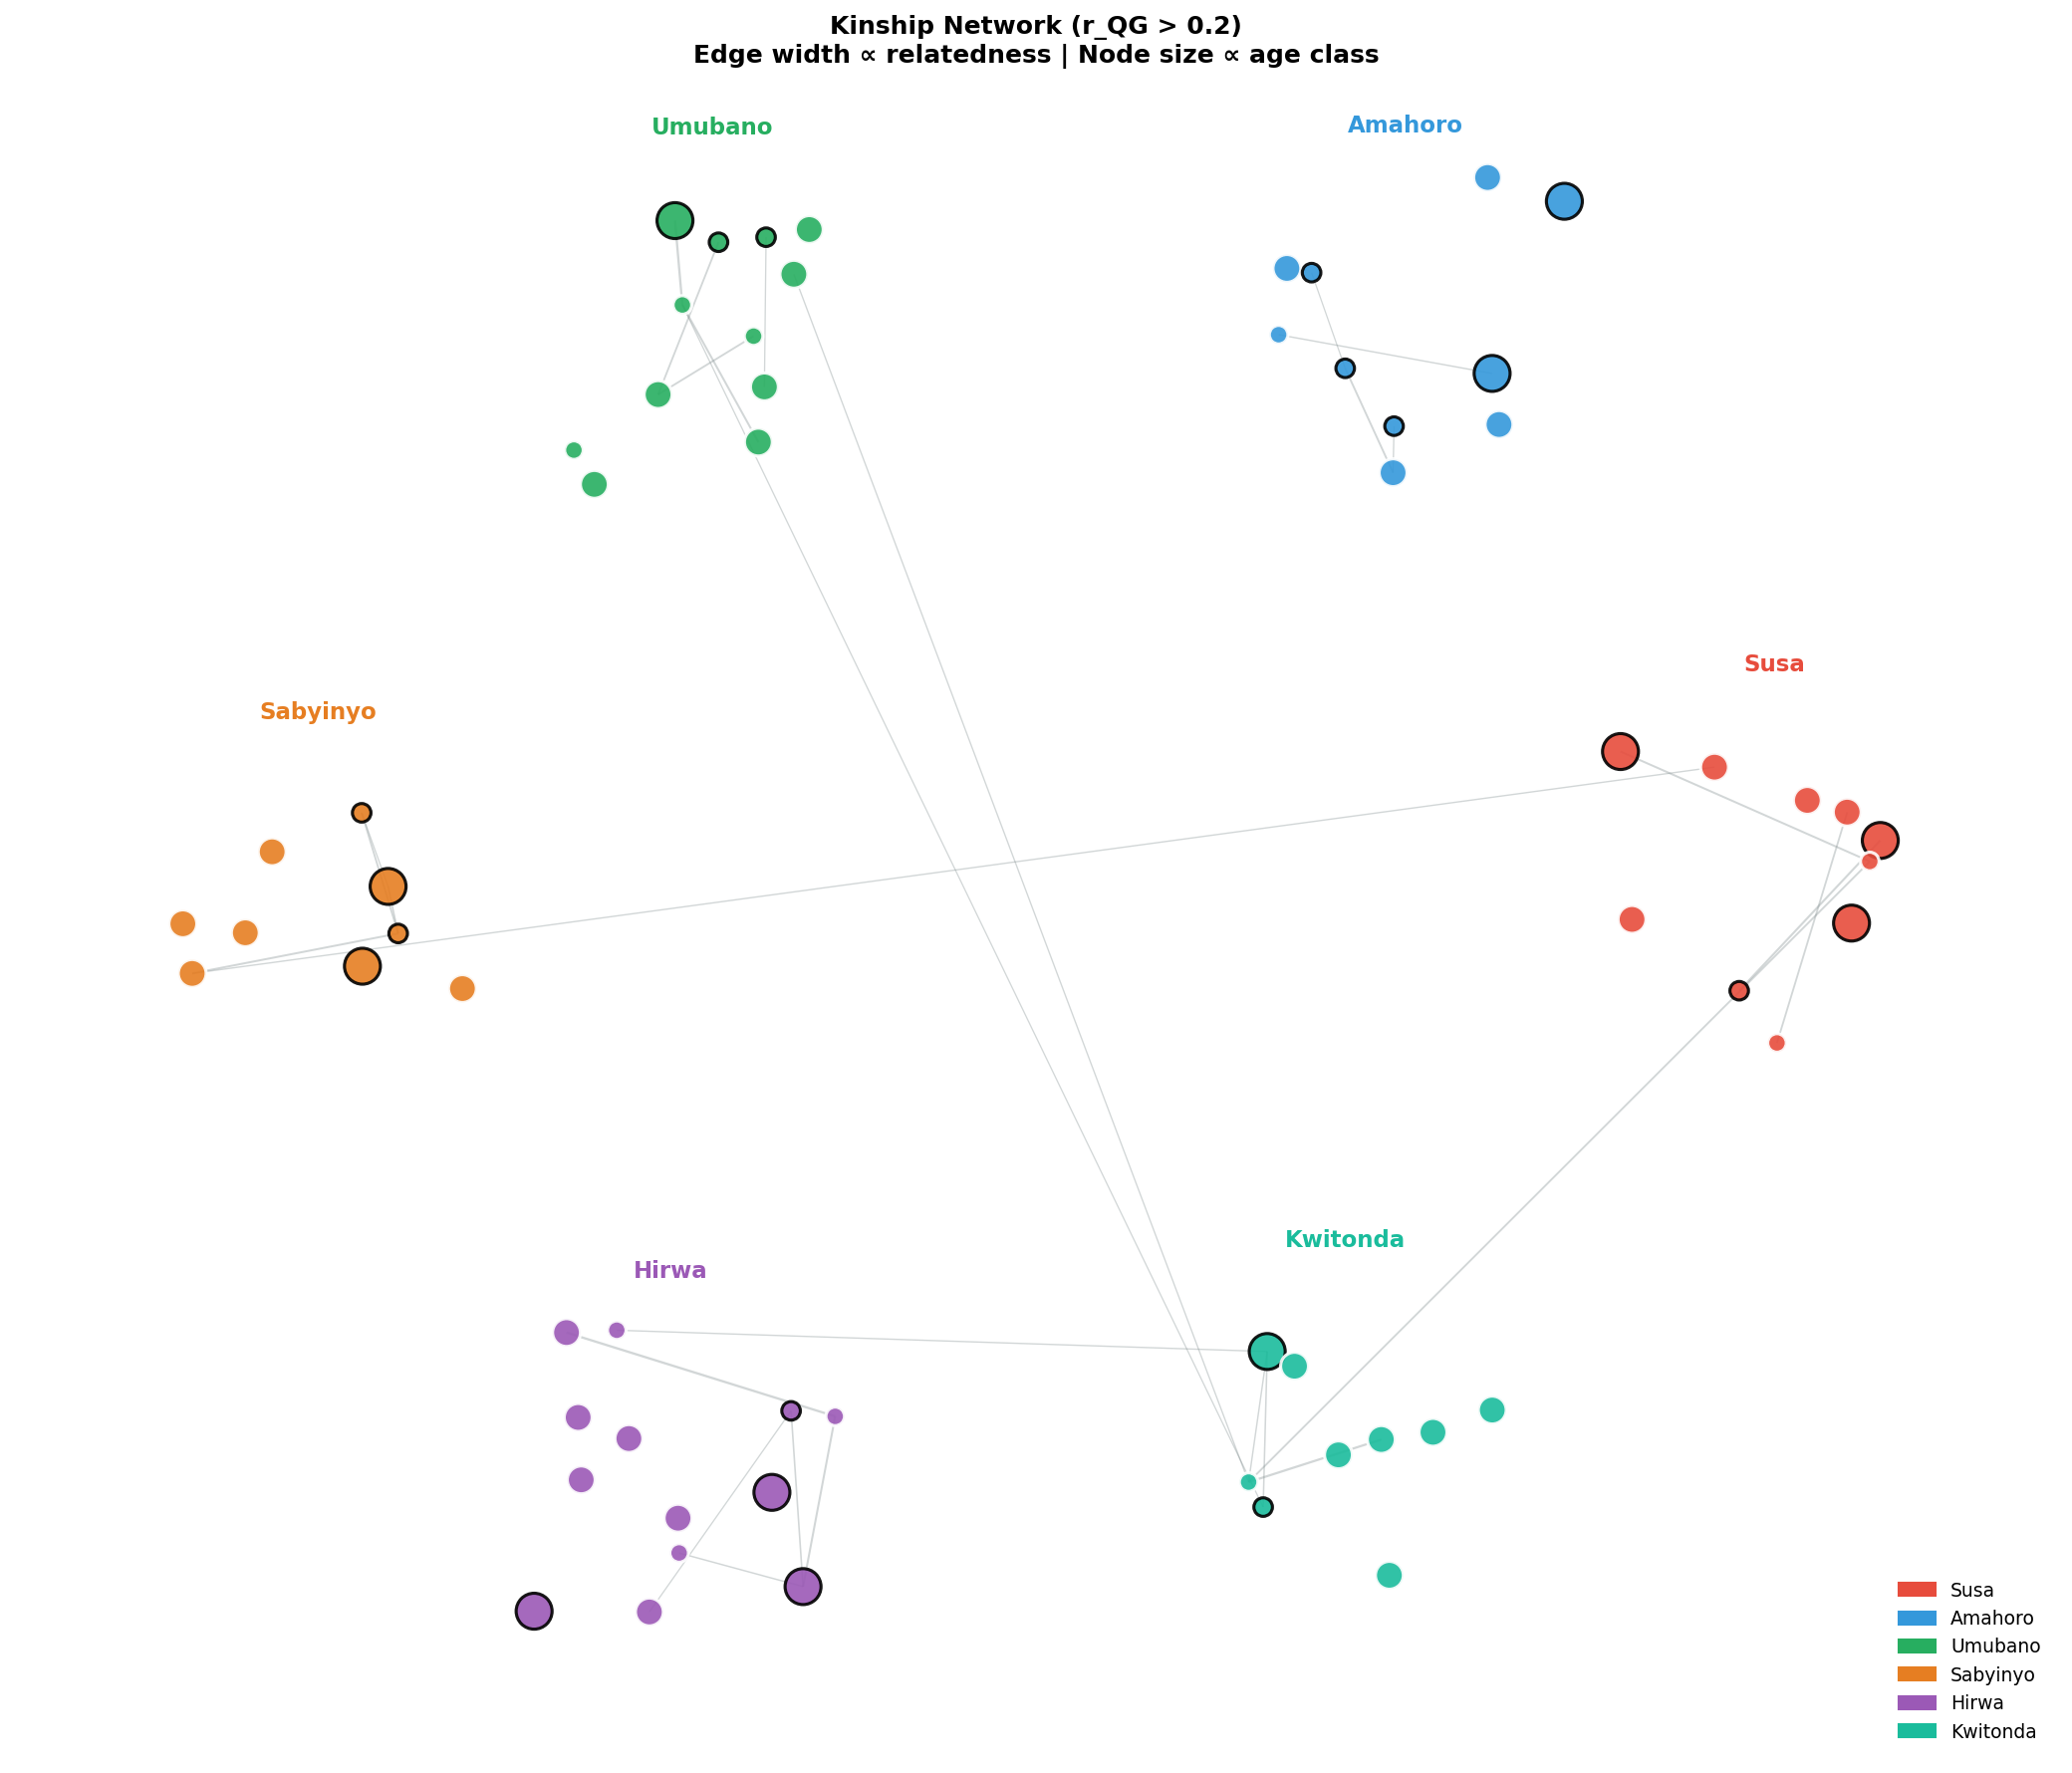

In [8]:
# Cell 7 — Kinship network graph
KINSHIP_THRESHOLD = 0.20

G = nx.Graph()
for _, row in ind_df.iterrows():
    G.add_node(row['individual_id'], group=row['group_id'],
               age_class=row['age_class'], sex=row['sex'])

high_rel = pairwise_df[pairwise_df['r_qg'] > KINSHIP_THRESHOLD]
for _, row in high_rel.iterrows():
    G.add_edge(row['id1'], row['id2'], weight=float(row['r_qg']))

print(f'Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges (r > {KINSHIP_THRESHOLD})')

group_ids_sorted = sorted(id_group_series.unique())
group_color_map  = {gid: c for gid, c in
                    zip(group_ids_sorted,
                        ['#E74C3C','#3498DB','#27AE60','#E67E22','#9B59B6','#1ABC9C'])}

rng = np.random.default_rng(42)
pos = {}
for i, gid in enumerate(group_ids_sorted):
    angle = 2 * np.pi * i / len(group_ids_sorted)
    ox, oy = 2.5 * np.cos(angle), 2.5 * np.sin(angle)
    for node in [n for n in G.nodes() if G.nodes[n]['group']==gid]:
        pos[node] = (ox + rng.uniform(-0.6,0.6), oy + rng.uniform(-0.6,0.6))

fig, ax = plt.subplots(figsize=(14, 12))
node_colors = [group_color_map.get(G.nodes[n]['group'],'grey') for n in G.nodes()]
node_sizes  = [300 if G.nodes[n]['age_class']=='silverback' else
               180 if G.nodes[n]['age_class']=='adult' else 80 for n in G.nodes()]
node_borders= ['black' if G.nodes[n]['sex']=='M' else 'white' for n in G.nodes()]
edge_weights= [G[u][v]['weight'] for u,v in G.edges()]

nx.draw_networkx_edges(G, pos, ax=ax, width=[w*3 for w in edge_weights], alpha=0.35, edge_color='#7F8C8D')
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                        edgecolors=node_borders, linewidths=1.5, alpha=0.9)

for gid in group_ids_sorted:
    g_nodes = [n for n in G.nodes() if G.nodes[n]['group']==gid]
    if not g_nodes: continue
    cx = np.mean([pos[n][0] for n in g_nodes])
    cy = np.mean([pos[n][1] for n in g_nodes])
    label = groups_df[groups_df['id']==gid]['name'].values
    ax.text(cx, cy+0.75, label[0] if len(label) else gid,
            ha='center', fontsize=11, fontweight='bold',
            color=group_color_map.get(gid,'black'))

legend_p = [mpatches.Patch(color=group_color_map[g],
                             label=groups_df[groups_df['id']==g]['name'].values[0]
                             if len(groups_df[groups_df['id']==g]) else g)
             for g in group_ids_sorted]
ax.legend(handles=legend_p, loc='lower right', fontsize=9)
ax.set_title(f'Kinship Network (r_QG > {KINSHIP_THRESHOLD})\nEdge width ∝ relatedness | Node size ∝ age class',
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
save_figure(fig, '04_kinship_network')
plt.show()

In [9]:
# Cell 8 — Within- vs Between-group relatedness summary
grp_rel_summary = group_relatedness_summary(pairwise_df, ind_df, r_col='r_qg')
print('--- Relatedness within vs between groups ---')
print(grp_rel_summary.round(4))
grp_rel_summary.to_csv(TAB_DIR / 'within_between_relatedness.csv')

stat, p_mw2 = mannwhitneyu(
    pairwise_df[pairwise_df['context']=='within']['r_qg'].dropna(),
    pairwise_df[pairwise_df['context']=='between']['r_qg'].dropna(),
    alternative='greater'
)
print(f'\nMann-Whitney U (within > between): U={stat:.0f}, p={p_mw2:.6f}')
sig = 'significantly' if p_mw2 < 0.05 else 'NOT significantly'
print(f'Within-group relatedness is {sig} higher than between groups.')

--- Relatedness within vs between groups ---
         mean_r  median_r    sd_r  n_pairs
context                                   
between -0.0153   -0.0184  0.0701     1647
within   0.0203   -0.0012  0.1074      306

Mann-Whitney U (within > between): U=294336, p=0.000001
Within-group relatedness is significantly higher than between groups.


In [10]:
# Cell 9 — Per-group internal relatedness
group_rel_rows = []
for gid in ind_df['group_id'].unique():
    g_inds  = set(ind_df[ind_df['group_id']==gid]['individual_id'])
    g_pairs = pairwise_df[
        pairwise_df['id1'].isin(g_inds) & pairwise_df['id2'].isin(g_inds)
    ]
    if g_pairs.empty: continue
    grp_name = groups_df[groups_df['id']==gid]['name'].values
    group_rel_rows.append({
        'group_id':       gid,
        'name':           grp_name[0] if len(grp_name) else gid,
        'n_pairs':        len(g_pairs),
        'mean_r_qg':      round(g_pairs['r_qg'].mean(), 4),
        'median_r':       round(g_pairs['r_qg'].median(), 4),
        'sd_r':           round(g_pairs['r_qg'].std(), 4),
        'max_r':          round(g_pairs['r_qg'].max(), 4),
        'pct_r_gt_025':   round(100*(g_pairs['r_qg'] > 0.25).mean(), 1),
    })

grp_int_df = pd.DataFrame(group_rel_rows)
print('--- Per-group internal relatedness ---')
print(grp_int_df.to_string(index=False))
grp_int_df.to_csv(TAB_DIR / 'per_group_relatedness.csv', index=False)

--- Per-group internal relatedness ---
group_id     name  n_pairs  mean_r_qg  median_r   sd_r  max_r  pct_r_gt_025
      G1     Susa       45     0.0108   -0.0157 0.1213 0.3337           6.7
      G2  Amahoro       45     0.0307    0.0072 0.1029 0.3046           2.2
      G3  Umubano       66     0.0172   -0.0046 0.1030 0.3681           6.1
      G4 Sabyinyo       36     0.0320    0.0073 0.1068 0.3179           8.3
      G5    Hirwa       78     0.0123   -0.0149 0.1098 0.3715           3.8
      G6 Kwitonda       36     0.0307    0.0087 0.1017 0.3582           2.8


  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\04_per_group_kinship.png


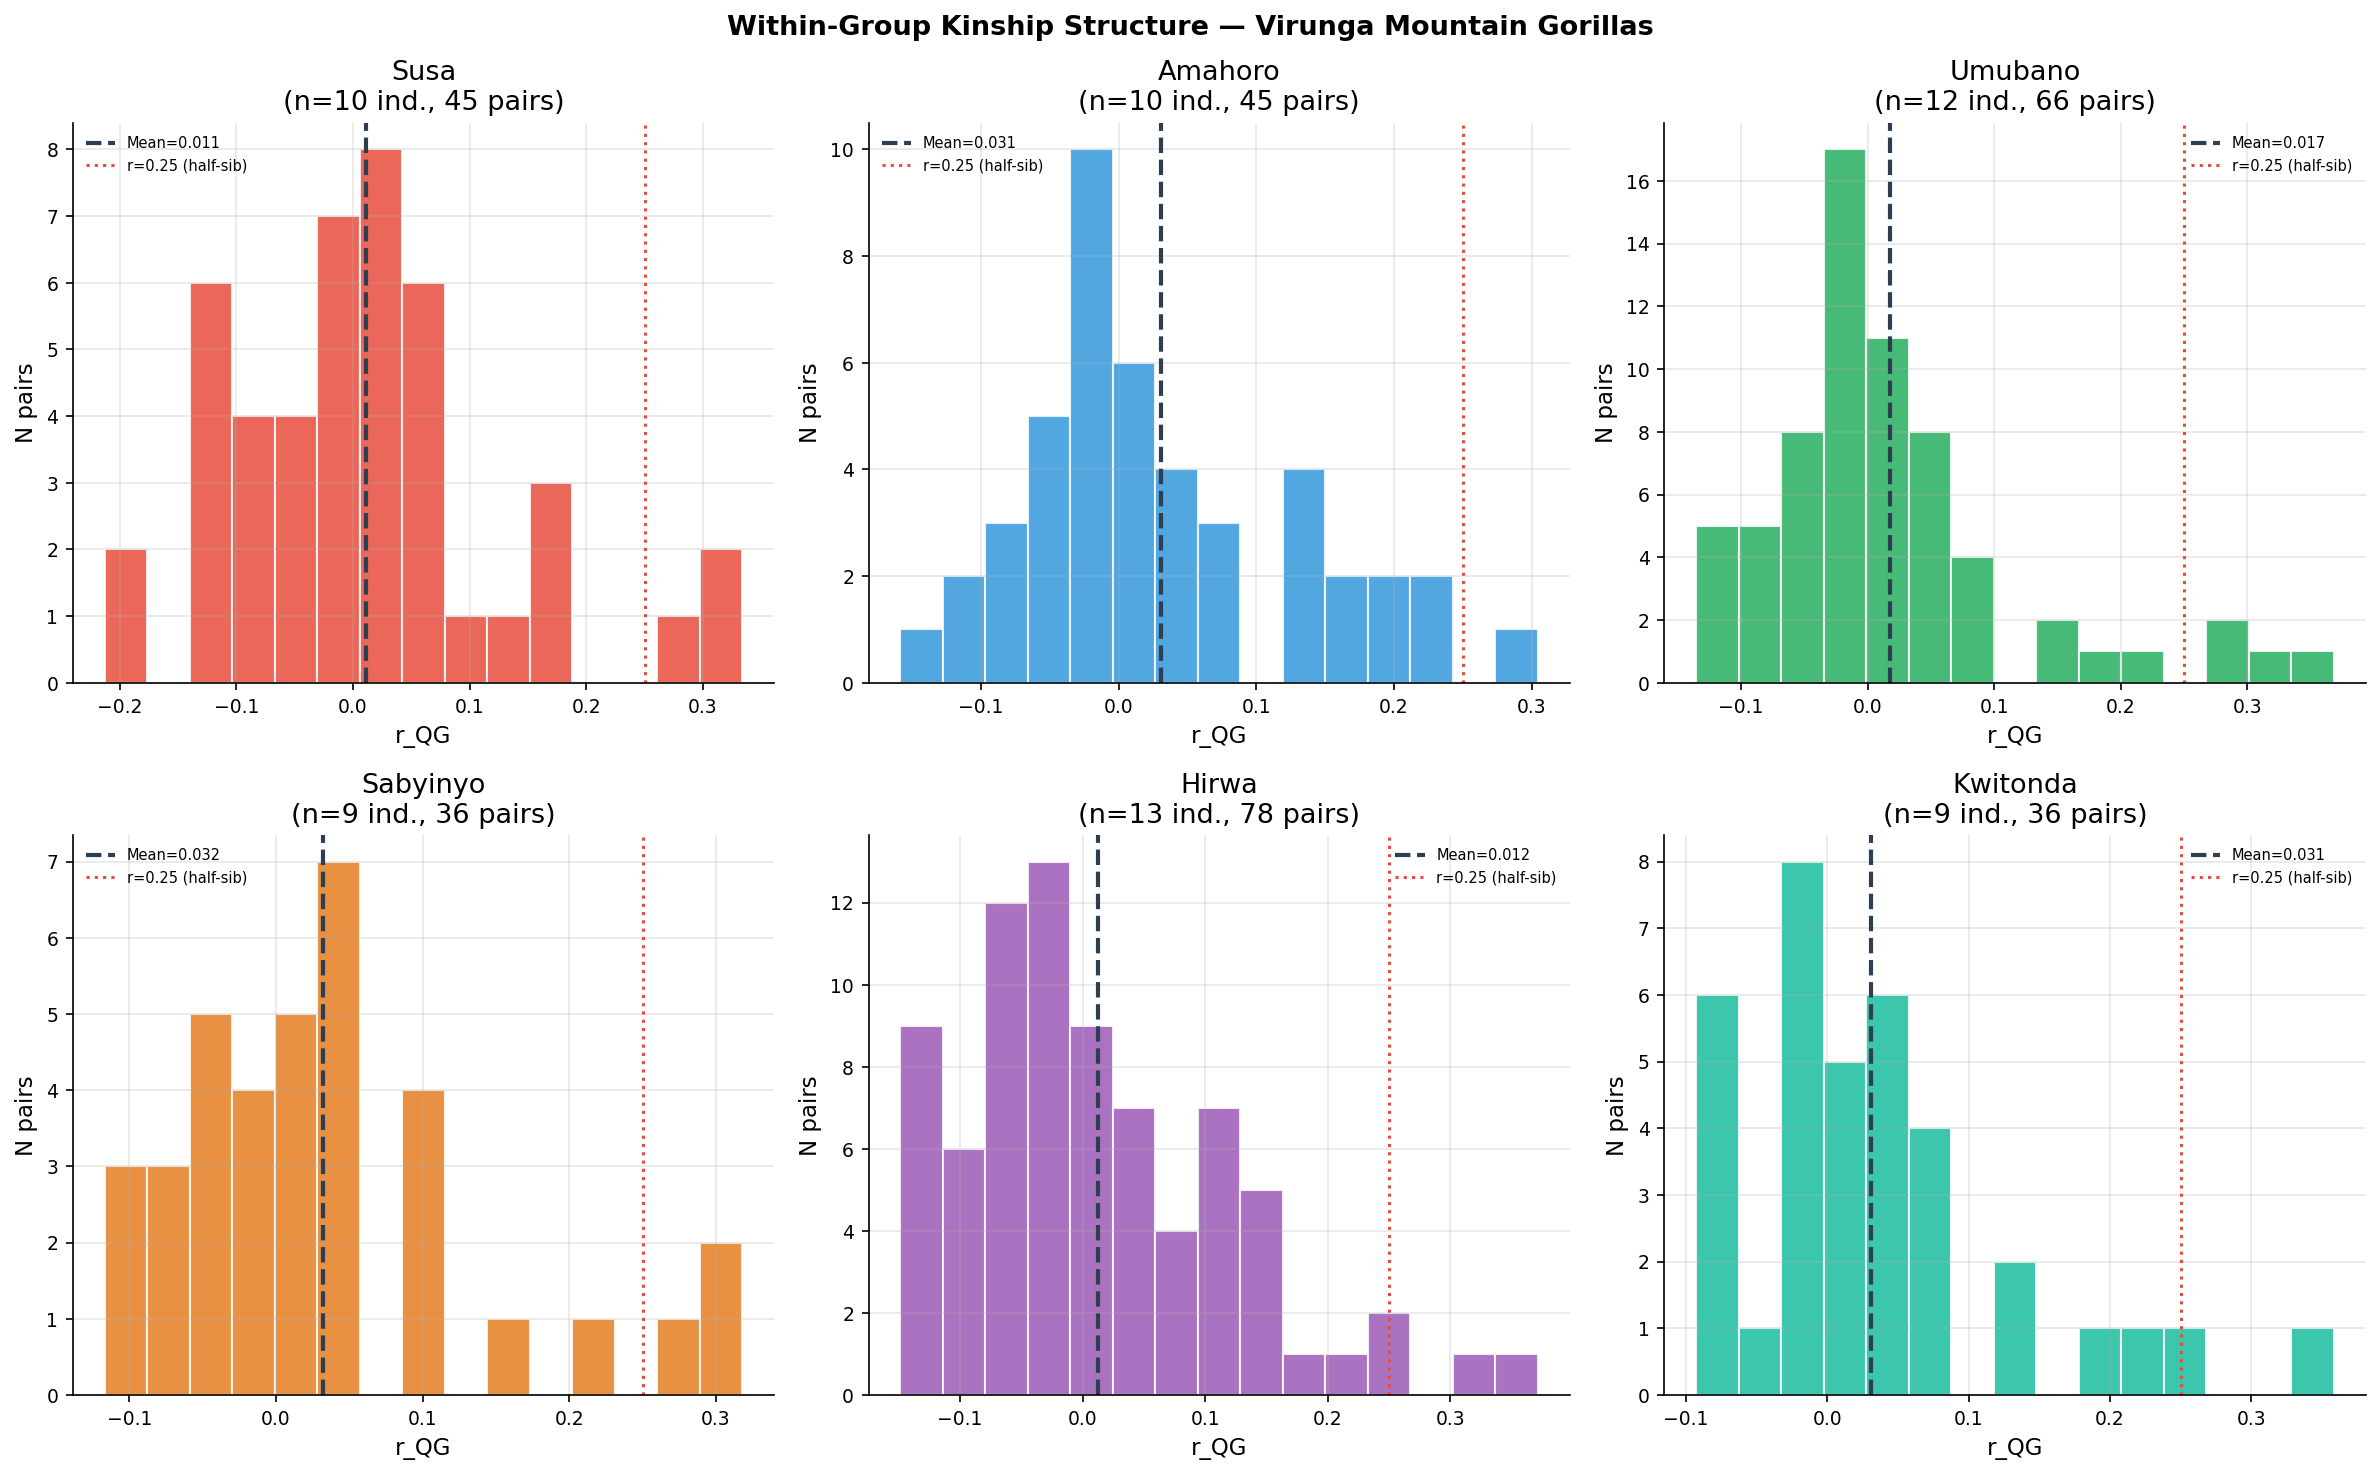


Notebook 04 complete. Proceed to 05_results_and_conservation.ipynb


In [11]:
# Cell 10 — Per-group kinship histogram grid
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Within-Group Kinship Structure — Virunga Mountain Gorillas',
             fontsize=13, fontweight='bold')
axes  = axes.flatten()
pal   = ['#E74C3C','#3498DB','#27AE60','#E67E22','#9B59B6','#1ABC9C']
gids  = sorted(ind_df['group_id'].unique())

for i, gid in enumerate(gids):
    ax     = axes[i]
    color  = pal[i % len(pal)]
    g_inds = set(ind_df[ind_df['group_id']==gid]['individual_id'])
    g_pairs= pairwise_df[
        pairwise_df['id1'].isin(g_inds) & pairwise_df['id2'].isin(g_inds)
    ]['r_qg'].dropna()
    grp_name = groups_df[groups_df['id']==gid]['name'].values

    ax.hist(g_pairs, bins=15, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(g_pairs.mean(), color='#2C3E50', lw=2, ls='--',
               label=f'Mean={g_pairs.mean():.3f}')
    ax.axvline(0.25, color='#E74C3C', lw=1.5, ls=':', label='r=0.25 (half-sib)')
    ax.set_xlabel('r_QG'); ax.set_ylabel('N pairs')
    ax.set_title(f'{grp_name[0] if len(grp_name) else gid}\n(n={len(g_inds)} ind., {len(g_pairs)} pairs)')
    ax.legend(fontsize=7)

plt.tight_layout()
save_figure(fig, '04_per_group_kinship')
plt.show()
print('\nNotebook 04 complete. Proceed to 05_results_and_conservation.ipynb')